Found 1 JSON files to process.
Json Files: ['kegg_nodes_metrics.json']
{'avg norm rank of source_mean': {'pdgrapher': [], 'pdgraphernognn': [], 'experiment': [], 'avg_degree': []}, 'accuracy_mean': {'pdgrapher': [], 'pdgraphernognn': [], 'experiment': [], 'avg_degree': []}, 'source in top 20_mean': {'pdgrapher': [], 'pdgraphernognn': [], 'experiment': [], 'avg_degree': []}}


ValueError: min() iterable argument is empty

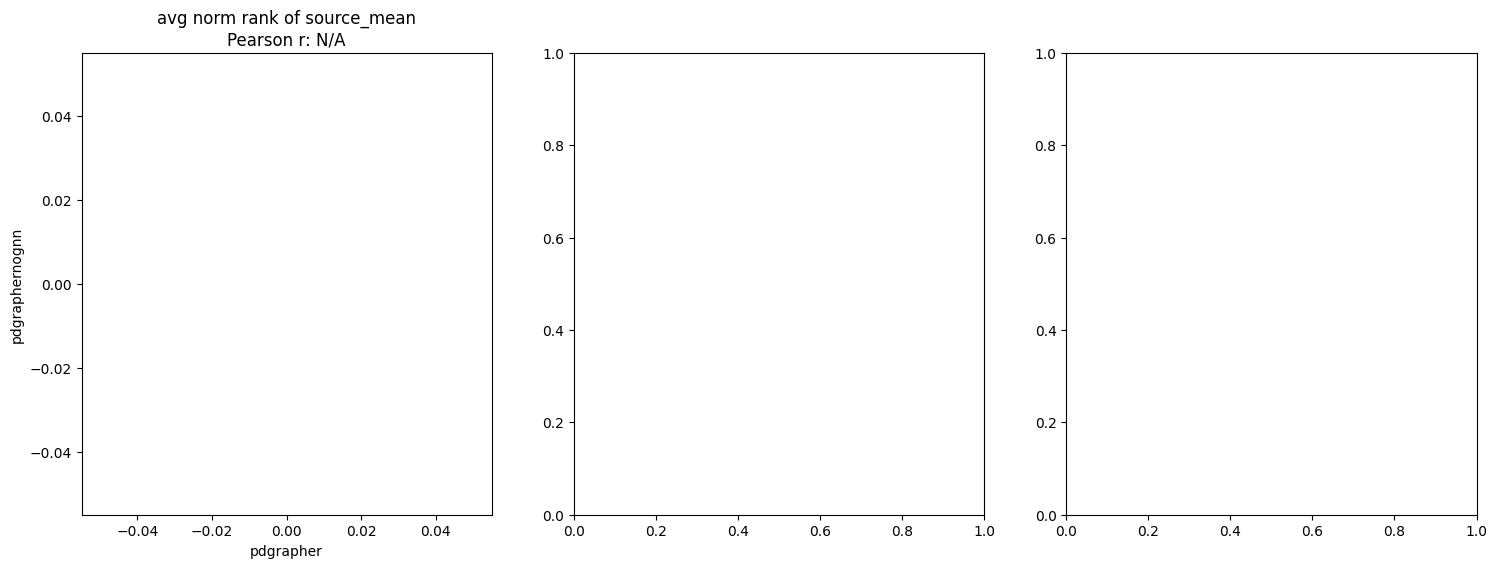

In [3]:
#in the current directory there are multible .json files. The files are structured as follows:
# {
#   "experiment": "egfr",
#   "timestamp": "0105_0950",
#   "k_folds": 5,
#   "results": {
    # "pdgrapher": {
    #   "num_folds": 5,
    #   "accuracy_mean": 0.1308,

# I will define a list of metrics. For each metric you will create a scatter plot comparing
# the results of 'pdgrapher' and 'pdgraphernognn' across all json files. 
# Each point in the scatter plot will represent one json file and will be named according to the "experiment" field in the json file.
# The x-axis will represent the 'pdgrapher' results and the y-axis will represent the 'pdgraphernognn' results.
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from matplotlib.colors import LogNorm
import scipy.stats as stats

# Define the metrics to compare
metrics = ["avg norm rank of source_mean", "accuracy_mean", "source in top 20_mean"]

kegg_file = "kegg_nodes_metrics.json"
if not os.path.exists(kegg_file):
    raise FileNotFoundError(f"Required file '{kegg_file}' not found in the current directory.")

with open(kegg_file, "r") as f:
    kegg_metadata = json.load(f)

def normalize_name(name: str) -> str:
    base = name.lower()
    base = base.replace("_", " ")
    base = base.replace("-", " ")
    base = base.split("(")[0]
    base = base.replace("pathway", "")
    base = base.strip()
    return "_".join(base.split())

kegg_avg_degree = {}
for raw_name, metadata in kegg_metadata.items():
    assert "average_degree" in metadata, f"'average_degree' missing for entry '{raw_name}'."
    kegg_avg_degree[normalize_name(raw_name)] = metadata["average_degree"]

data = {metric: {"pdgrapher": [], "pdgraphernognn": [], "experiment": [], "avg_degree": []} for metric in metrics}
json_files = glob("*.json")
if not json_files:
    raise FileNotFoundError("No JSON files found matching pattern '*.json' in the current directory.")

print(f"Found {len(json_files)} JSON files to process.")
print(f"Json Files: {json_files}")

for file in json_files:
    # if the file is the kegg_file, skip it
    if file == kegg_file:
        continue
    with open(file, "r") as f:
        content = json.load(f)

    experiment = content.get("experiment")
    if experiment is None:
        raise ValueError(f"'experiment' key missing in file '{file}'.")
    normalized_experiment = normalize_name(experiment)
    # check all keys in kegg_avg_degree if they contain the normalized_experiment as substring
    for key in kegg_avg_degree.keys():
        if normalized_experiment in key:
            normalized_experiment = key
            break
    if normalized_experiment not in kegg_avg_degree:
        raise ValueError(f"Experiment '{experiment}' (normalized as '{normalized_experiment}') not found in KEGG metadata.")
    
    avg_degree_value = kegg_avg_degree[normalized_experiment]

    results = content.get("results")
    if results is None:
        raise ValueError(f"'results' key missing in file '{file}'.")
    pdgrapher_results = results.get("pdgrapher")
    pdgraphernognn_results = results.get("pdgraphernognn")
    if pdgrapher_results is None or pdgraphernognn_results is None:
        raise ValueError(f"Both 'pdgrapher' and 'pdgraphernognn' results must be present in file '{file}'.")

    for metric in metrics:
        if metric not in pdgrapher_results or metric not in pdgraphernognn_results:
            raise ValueError(f"Metric '{metric}' missing in file '{file}'.")
        data[metric]["pdgrapher"].append(pdgrapher_results[metric])
        data[metric]["pdgraphernognn"].append(pdgraphernognn_results[metric])
        data[metric]["experiment"].append(experiment)
        data[metric]["avg_degree"].append(avg_degree_value)

color_norm = plt.Normalize(min(kegg_avg_degree.values()), max(kegg_avg_degree.values()))
num_metrics = len(metrics)
fig, axs = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 6))
if num_metrics == 1:
    axs = [axs]

print(data)

color_norm = LogNorm(vmin=1.0, vmax=max(kegg_avg_degree.values()))
mappable = None
for i, metric in enumerate(metrics):
    ax = axs[i]
    x = data[metric]["pdgrapher"]
    y = data[metric]["pdgraphernognn"]
    experiments = data[metric]["experiment"]
    avg_deg = data[metric]["avg_degree"]

    scatter = ax.scatter(x, y, c=avg_deg, cmap="viridis", norm=color_norm)
    mappable = scatter

    for j, experiment in enumerate(experiments):
        ax.annotate(experiment, (x[j], y[j]), textcoords="offset points", xytext=(0, 10), ha="center")

    if len(x) > 1 and len(y) > 1:
        corr, _ = pearsonr(x, y)
        ax.set_title(f"{metric}\nPearson r: {corr:.2f}")
    else:
        ax.set_title(f"{metric}\nPearson r: N/A")

    ax.set_xlabel("pdgrapher")
    ax.set_ylabel("pdgraphernognn")
    diag_min = min(min(x), min(y))
    diag_max = max(max(x), max(y))
    ax.plot([diag_min, diag_max], [diag_min, diag_max], "r--")

if mappable is None:
    raise RuntimeError("No scatter plot was created; verify that the input data contains the requested metrics.")

fig.colorbar(mappable, ax=axs, label="Average degree (log scale)", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("comparison_scatter_plots.png")

ValueError: min() iterable argument is empty

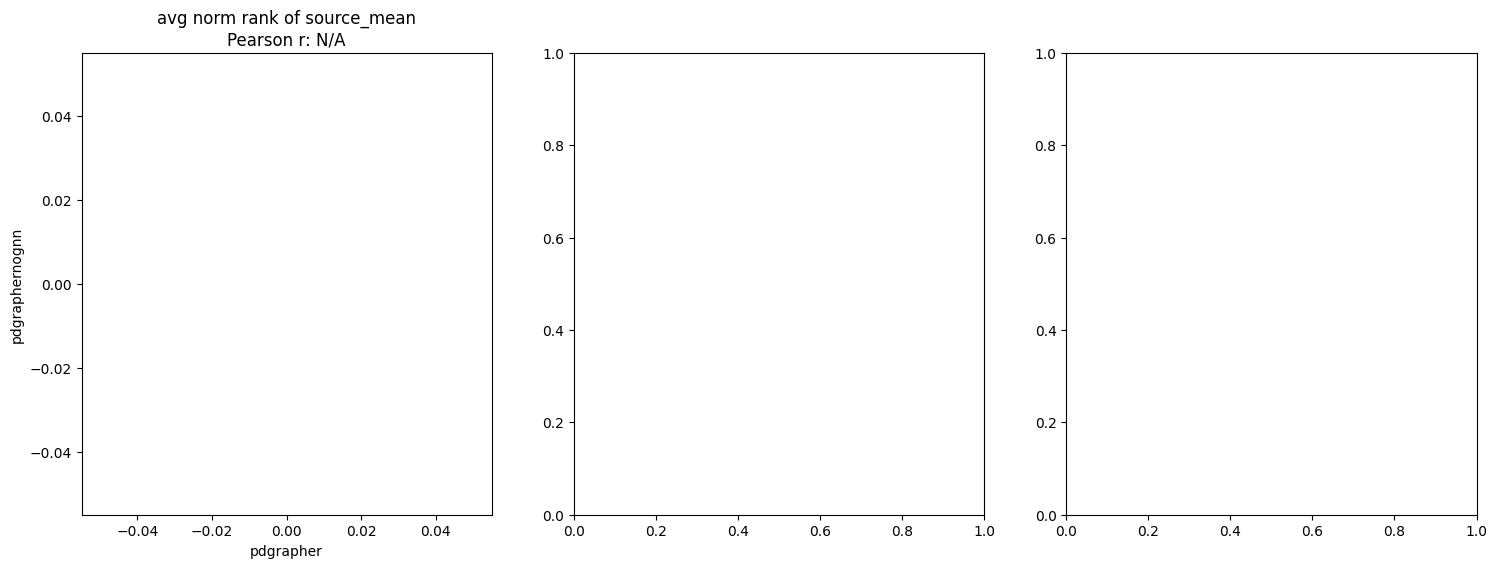

In [ ]:
# Define the metadata metrics to use for coloring
metadata_metrics = ["average_degree", "density", "number_of_nodes", "number_of_perturbed_genes_in_pathway", "number_of_edges", "number_of_sig_info_in_pathway"]

# For each metadata metric, create a separate figure with scatter plots
for metadata_name in metadata_metrics:
    # Extract metadata values for all experiments
    metadata_values = {}
    for raw_name, metadata in kegg_metadata.items():
        assert metadata_name in metadata, f"'{metadata_name}' missing for entry '{raw_name}'."
        metadata_values[normalize_name(raw_name)] = metadata[metadata_name]
    
    # Build data structure with metadata values for each experiment
    data_with_metadata = {metric: {"pdgrapher": [], "pdgraphernognn": [], "experiment": [], "metadata": []} for metric in metrics}
    
    for file in json_files:
        if file == kegg_file:
            continue
        with open(file, "r") as f:
            content = json.load(f)
        
        experiment = content.get("experiment")
        if experiment is None:
            raise ValueError(f"'experiment' key missing in file '{file}'.")
        
        # Normalize experiment name (handle case variations)
        normalized_experiment = normalize_name(experiment)
        
        # Match normalized experiment to metadata keys
        matched = False
        for key in metadata_values.keys():
            if normalized_experiment in key:
                normalized_experiment = key
                matched = True
                break
        
        if not matched:
            raise ValueError(
                f"Experiment '{experiment}' (normalized as '{normalized_experiment}') "
                f"not found in KEGG metadata for metric '{metadata_name}'."
            )
        
        metadata_value = metadata_values[normalized_experiment]
        
        results = content.get("results")
        if results is None:
            raise ValueError(f"'results' key missing in file '{file}'.")
        pdgrapher_results = results.get("pdgrapher")
        pdgraphernognn_results = results.get("pdgraphernognn")
        if pdgrapher_results is None or pdgraphernognn_results is None:
            raise ValueError(f"Both 'pdgrapher' and 'pdgraphernognn' results must be present in file '{file}'.")
        
        for metric in metrics:
            if metric not in pdgrapher_results or metric not in pdgraphernognn_results:
                raise ValueError(f"Metric '{metric}' missing in file '{file}'.")
            data_with_metadata[metric]["pdgrapher"].append(pdgrapher_results[metric])
            data_with_metadata[metric]["pdgraphernognn"].append(pdgraphernognn_results[metric])
            data_with_metadata[metric]["experiment"].append(experiment)
            data_with_metadata[metric]["metadata"].append(metadata_value)
    
    # Create figure for this metadata metric
    fig_metadata, axs_metadata = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 6))
    if num_metrics == 1:
        axs_metadata = [axs_metadata]
    
    # Determine color normalization
    min_metadata = min(metadata_values.values())
    max_metadata = max(metadata_values.values())
    color_norm_metadata = LogNorm(vmin=max(min_metadata, 1e-6), vmax=max_metadata)
    
    mappable_metadata = None
    for i, metric in enumerate(metrics):
        ax_metadata = axs_metadata[i]
        x = data_with_metadata[metric]["pdgrapher"]
        y = data_with_metadata[metric]["pdgraphernognn"]
        experiments = data_with_metadata[metric]["experiment"]
        metadata_vals = data_with_metadata[metric]["metadata"]
        
        scatter_metadata = ax_metadata.scatter(x, y, c=metadata_vals, cmap="viridis", norm=color_norm_metadata)
        mappable_metadata = scatter_metadata
        
        for j, experiment in enumerate(experiments):
            ax_metadata.annotate(experiment, (x[j], y[j]), textcoords="offset points", xytext=(0, 10), ha="center")
        
        if len(x) > 1 and len(y) > 1:
            corr, _ = pearsonr(x, y)
            ax_metadata.set_title(f"{metric}\nPearson r: {corr:.2f}")
        else:
            ax_metadata.set_title(f"{metric}\nPearson r: N/A")
        
        ax_metadata.set_xlabel("pdgrapher")
        ax_metadata.set_ylabel("pdgraphernognn")
        diag_min = min(min(x), min(y))
        diag_max = max(max(x), max(y))
        ax_metadata.plot([diag_min, diag_max], [diag_min, diag_max], "r--")
    
    if mappable_metadata is None:
        raise RuntimeError("No scatter plot was created; verify that the input data contains the requested metrics.")
    
    fig_metadata.colorbar(mappable_metadata, ax=axs_metadata, label=f"{metadata_name} (log scale)", fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(f"comparison_scatter_plots_{metadata_name}.png")
    plt.close(fig_metadata)


In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from scipy.stats import pearsonr
from matplotlib.colors import LogNorm

# =========================
# Configuration
# =========================

metrics = [
    "avg norm rank of source_mean",
    "accuracy_mean",
    "source in top 20_mean",
]

kegg_file = "kegg_nodes_metrics.json"

# =========================
# Helpers
# =========================

def normalize_name(name: str) -> str:
    base = name.lower()
    base = base.replace("_", " ")
    base = base.replace("-", " ")
    base = base.split("(")[0]
    base = base.replace("pathway", "")
    base = base.strip()
    return "_".join(base.split())

# =========================
# Load KEGG metadata
# =========================

if not os.path.exists(kegg_file):
    raise FileNotFoundError(f"Required file '{kegg_file}' not found.")

with open(kegg_file, "r") as f:
    kegg_metadata = json.load(f)

kegg_avg_degree = {}
for raw_name, metadata in kegg_metadata.items():
    assert "average_degree" in metadata
    kegg_avg_degree[normalize_name(raw_name)] = metadata["average_degree"]

# =========================
# Load experiment results
# =========================

data = {
    metric: {
        "pdgrapher": [],
        "pdgraphernognn": [],
        "pdgrapher_std": [],
        "pdgraphernognn_std": [],
        "experiment": [],
        "avg_degree": [],
    }
    for metric in metrics
}

json_files = []
for entry in os.listdir("."):
    if os.path.isdir(entry):
        subdir_files = glob(os.path.join(entry, "*.json"))
        json_files.extend(subdir_files)

if not json_files:
    raise FileNotFoundError("No JSON files found in subdirectories.")

for file in json_files:
    if file == kegg_file:
        continue

    with open(file, "r") as f:
        content = json.load(f)

    experiment = content.get("experiment")
    if experiment is None:
        raise ValueError(f"'experiment' missing in {file}")

    normalized_experiment = normalize_name(experiment)
    for key in kegg_avg_degree:
        if normalized_experiment in key:
            normalized_experiment = key
            break

    if normalized_experiment not in kegg_avg_degree:
        raise ValueError(f"Experiment '{experiment}' not found in KEGG metadata.")

    avg_degree_value = kegg_avg_degree[normalized_experiment]

    results = content.get("results")
    if results is None:
        raise ValueError(f"'results' missing in {file}")

    pdg = results.get("pdgrapher")
    pdg_ng = results.get("pdgraphernognn")
    if pdg is None or pdg_ng is None:
        raise ValueError(f"Both methods missing in {file}")

    for metric in metrics:
        std_metric = metric.replace("_mean", "_std")

        if (
            metric not in pdg
            or metric not in pdg_ng
            or std_metric not in pdg
            or std_metric not in pdg_ng
        ):
            raise ValueError(f"Metric '{metric}' or '{std_metric}' missing in {file}")

        data[metric]["pdgrapher"].append(pdg[metric])
        data[metric]["pdgraphernognn"].append(pdg_ng[metric])
        data[metric]["pdgrapher_std"].append(pdg[std_metric])
        data[metric]["pdgraphernognn_std"].append(pdg_ng[std_metric])
        data[metric]["experiment"].append(experiment)
        data[metric]["avg_degree"].append(avg_degree_value)

# find a nice way to print data to verify correctness
for metric in metrics:
    print(f"Metric: {metric}")
    for i in range(len(data[metric]["experiment"])):
        print(
            f"  Experiment: {data[metric]['experiment'][i]}, "
            f"pdgrapher: {data[metric]['pdgrapher'][i]} ± {data[metric]['pdgrapher_std'][i]}, "
            f"pdgraphernognn: {data[metric]['pdgraphernognn'][i]} ± {data[metric]['pdgraphernognn_std'][i]}, "
            f"avg_degree: {data[metric]['avg_degree'][i]}"
        )

# =========================
# Plot: comparison scatter with error bars
# =========================

num_metrics = len(metrics)
fig, axs = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 6))
if num_metrics == 1:
    axs = [axs]

color_norm = LogNorm(vmin=1.0, vmax=max(kegg_avg_degree.values()))
mappable = None

for i, metric in enumerate(metrics):
    ax = axs[i]

    x = data[metric]["pdgrapher"]
    y = data[metric]["pdgraphernognn"]
    xerr = data[metric]["pdgrapher_std"]
    yerr = data[metric]["pdgraphernognn_std"]
    experiments = data[metric]["experiment"]
    avg_deg = data[metric]["avg_degree"]

    scatter = ax.scatter(
        x,
        y,
        c=avg_deg,
        cmap="viridis",
        norm=color_norm,
        s=90,              # <-- bigger markers
        edgecolors="black",
        linewidths=0.5,
        zorder=2,
    )

    mappable = scatter

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=1,
        alpha=0.6,
        capsize=3,
        zorder=1,
    )

    for j, experiment in enumerate(experiments):
        ax.annotate(
            experiment,
            (x[j], y[j]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
        )

    if len(x) > 1:
        corr, _ = pearsonr(x, y)
        ax.set_title(f"{metric}\nPearson r = {corr:.2f}")
    else:
        ax.set_title(metric)

    ax.set_xlabel("pdgrapher")
    ax.set_ylabel("pdgraphernognn")

    diag_min = min(min(x), min(y))
    diag_max = max(max(x), max(y))
    ax.plot([diag_min, diag_max], [diag_min, diag_max], "r--", alpha=0.7)

plt.tight_layout(rect=[0, 0, 0.9, 1])

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label("Average degree (log scale)")

plt.savefig("comparison_scatter_plots.png")
plt.close(fig)


Metric: avg norm rank of source_mean
  Experiment: MAPK_signaling, pdgrapher: 0.2554 ± 0.0138, pdgraphernognn: 0.2762 ± 0.0103, avg_degree: 16.554054054054053
  Experiment: apoptosis, pdgrapher: 0.2408 ± 0.0114, pdgraphernognn: 0.3624 ± 0.0095, avg_degree: 2.754385964912281
  Experiment: apoptosis, pdgrapher: 0.2906 ± 0.0069, pdgraphernognn: 0.2738 ± 0.0091, avg_degree: 2.754385964912281
  Experiment: apoptosis, pdgrapher: 0.2344 ± 0.0254, pdgraphernognn: 0.2626 ± 0.0337, avg_degree: 2.754385964912281
  Experiment: breast_cancer, pdgrapher: 0.2584 ± 0.0066, pdgraphernognn: 0.3048 ± 0.0124, avg_degree: 2.4
  Experiment: central_carbon_metabolism_in_cancer, pdgrapher: 0.2802 ± 0.0149, pdgraphernognn: 0.2504 ± 0.0117, avg_degree: 2.210526315789474
  Experiment: circadian_entrainment, pdgrapher: 0.2164 ± 0.0276, pdgraphernognn: 0.195 ± 0.0572, avg_degree: 6.233333333333333
  Experiment: colorectal_cancer, pdgrapher: 0.285 ± 0.0443, pdgraphernognn: 0.2888 ± 0.0536, avg_degree: 2.25
  Experi

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from scipy.stats import pearsonr
from matplotlib.colors import LogNorm, Normalize

# =========================
# Configuration
# =========================

metrics = [
    "avg norm rank of source_mean",
    "accuracy_mean",
    "source in top 20_mean",
]

kegg_file = "kegg_nodes_metrics.json"
metadata_metric_for_nodecolor = "number_of_nodes"

# =========================
# Helpers
# =========================

def normalize_name(name: str) -> str:
    base = name.lower()
    base = base.replace("_", " ")
    base = base.replace("-", " ")
    base = base.split("(")[0]
    base = base.replace("pathway", "")
    base = base.strip()
    return "_".join(base.split())


def aggregate_mean_std(stats):
    """
    stats: list of tuples (n, mean, std)
    returns: (mean, std)
    """
    total_n = sum(n for n, _, _ in stats)
    if total_n == 0:
        return np.nan, np.nan

    mean = sum(n * m for n, m, _ in stats) / total_n
    var = (
        sum(n * (s**2 + m**2) for n, m, s in stats) / total_n
        - mean**2
    )
    return mean, np.sqrt(var)

# =========================
# Load KEGG metadata
# =========================

if not os.path.exists(kegg_file):
    raise FileNotFoundError(f"Required file '{kegg_file}' not found.")

with open(kegg_file, "r") as f:
    kegg_metadata = json.load(f)

kegg_metric = {}
for raw_name, metadata in kegg_metadata.items():
    if metadata_metric_for_nodecolor not in metadata:
        continue
    kegg_metric[normalize_name(raw_name)] = metadata[metadata_metric_for_nodecolor]

# =========================
# Prepare data container
# =========================

data = {
    metric: {
        "pdgrapher": [],
        "pdgraphernognn": [],
        "pdgrapher_std": [],
        "pdgraphernognn_std": [],
        "experiment": [],
        "avg_degree": [],
    }
    for metric in metrics
}

# =========================
# Load experiment results
# =========================

experiment_dirs = [
    d for d in os.listdir(".")
    if os.path.isdir(d)
]

if not experiment_dirs:
    raise FileNotFoundError("No experiment directories found.")

for exp_dir in experiment_dirs:
    json_files = glob(os.path.join(exp_dir, "*.json"))
    if not json_files:
        continue

    accum = {
        metric: {
            "pdgrapher": [],
            "pdgraphernognn": [],
        }
        for metric in metrics
    }

    experiment_name = None
    metadata_value = None

    for file in json_files:
        with open(file, "r") as f:
            content = json.load(f)

        if experiment_name is None:
            experiment_name = content.get("experiment")
            if experiment_name is None:
                raise ValueError(f"'experiment' missing in {file}")

            normalized_experiment = normalize_name(experiment_name)
            for key in kegg_metric:
                if normalized_experiment in key:
                    normalized_experiment = key
                    break
            # try capitalized version as well
            for key in kegg_metric:
                if normalized_experiment.capitalize() in key:
                    normalized_experiment = key
                    break

            print(f"Mapping experiment '{experiment_name}' to KEGG entry '{normalized_experiment}' or '{normalized_experiment.capitalize()}'")

            if normalized_experiment not in kegg_metric:
                raise ValueError(
                    f"Experiment '{experiment_name}' not found in KEGG metadata."
                )

            metadata_value = kegg_metric[normalized_experiment]

        k_folds = content.get("k_folds")
        if k_folds is None:
            raise ValueError(f"'k_folds' missing in {file}")

        results = content.get("results")
        pdg = results.get("pdgrapher")
        pdg_ng = results.get("pdgraphernognn")

        for metric in metrics:
            std_metric = metric.replace("_mean", "_std")

            accum[metric]["pdgrapher"].append(
                (k_folds, pdg[metric], pdg[std_metric])
            )
            accum[metric]["pdgraphernognn"].append(
                (k_folds, pdg_ng[metric], pdg_ng[std_metric])
            )

    for metric in metrics:
        pdg_mean, pdg_std = aggregate_mean_std(accum[metric]["pdgrapher"])
        ng_mean, ng_std = aggregate_mean_std(accum[metric]["pdgraphernognn"])

        data[metric]["pdgrapher"].append(pdg_mean)
        data[metric]["pdgraphernognn"].append(ng_mean)
        data[metric]["pdgrapher_std"].append(pdg_std)
        data[metric]["pdgraphernognn_std"].append(ng_std)
        data[metric]["experiment"].append(experiment_name)
        data[metric]["avg_degree"].append(metadata_value)

# =========================
# Dynamic color normalization
# =========================

all_meta_values = np.array(
    [v for metric in metrics for v in data[metric]["avg_degree"]],
    dtype=float,
)

vmin = np.min(all_meta_values)
vmax = np.max(all_meta_values)

if vmin > 0 and vmax / vmin >= 100:
    color_norm = LogNorm(vmin=vmin, vmax=vmax)
    colorbar_label = f"{metadata_metric_for_nodecolor} (log scale)"
else:
    color_norm = Normalize(vmin=vmin, vmax=vmax)
    colorbar_label = metadata_metric_for_nodecolor

# =========================
# Plot
# =========================

num_metrics = len(metrics)
fig, axs = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 6))
if num_metrics == 1:
    axs = [axs]

mappable = None

for i, metric in enumerate(metrics):
    ax = axs[i]

    x = data[metric]["pdgrapher"]
    y = data[metric]["pdgraphernognn"]
    xerr = data[metric]["pdgrapher_std"]
    yerr = data[metric]["pdgraphernognn_std"]
    avg_deg = data[metric]["avg_degree"]
    experiments = data[metric]["experiment"]

    scatter = ax.scatter(
        x,
        y,
        c=avg_deg,
        cmap="viridis",
        norm=color_norm,
        s=90,
        edgecolors="black",
        linewidths=0.5,
        zorder=2,
    )
    mappable = scatter

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=1,
        alpha=0.6,
        capsize=3,
        zorder=1,
    )

    for j, experiment in enumerate(experiments):
        ax.annotate(
            experiment,
            (x[j], y[j]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
        )

    if len(x) > 1:
        corr, _ = pearsonr(x, y)
        ax.set_title(f"{metric}\nPearson r = {corr:.2f}")
    else:
        ax.set_title(metric)

    ax.set_xlabel("pdgrapher")
    ax.set_ylabel("pdgraphernognn")

    diag_min = min(min(x), min(y))
    diag_max = max(max(x), max(y))
    ax.plot([diag_min, diag_max], [diag_min, diag_max], "r--", alpha=0.7)

plt.tight_layout(rect=[0, 0, 0.9, 1])

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label(colorbar_label)

plt.savefig("comparison_scatter_plots.png")
plt.close(fig)


Mapping experiment 'MAPK_signaling' to KEGG entry 'mapk_signaling' or 'Mapk_signaling'
Mapping experiment 'apoptosis' to KEGG entry 'apoptosis' or 'Apoptosis'
Mapping experiment 'breast_cancer' to KEGG entry 'breast_cancer' or 'Breast_cancer'
Mapping experiment 'central_carbon_metabolism_in_cancer' to KEGG entry 'central_carbon_metabolism_in_cancer' or 'Central_carbon_metabolism_in_cancer'
Mapping experiment 'circadian_entrainment' to KEGG entry 'circadian_entrainment' or 'Circadian_entrainment'
Mapping experiment 'colorectal_cancer' to KEGG entry 'colorectal_cancer' or 'Colorectal_cancer'
Mapping experiment 'egfr' to KEGG entry 'egfr_signaling' or 'Egfr_signaling'
Mapping experiment 'endocrine_resistance' to KEGG entry 'endocrine_resistance' or 'Endocrine_resistance'
Mapping experiment 'estrogen_signaling' to KEGG entry 'estrogen_signaling' or 'Estrogen_signaling'
Mapping experiment 'human_papillomavirus_infection' to KEGG entry 'human_papillomavirus_infection' or 'Human_papillomaviru

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from scipy.stats import pearsonr
from matplotlib.colors import LogNorm, Normalize

# =========================
# Configuration
# =========================

metrics = [
    "avg norm rank of source_mean",
    "accuracy_mean",
    "source in top 20_mean",
]

metadata_metrics = [
    "average_degree", 
    "density", 
    "number_of_nodes", 
    "number_of_perturbed_genes_in_pathway", 
    "number_of_edges", 
    "number_of_sig_info_in_pathway"
]

kegg_file = "kegg_nodes_metrics.json"
metadata_metric_for_nodecolor = "number_of_perturbed_genes_in_pathway"

# Define ranges for filtering (optional)
# Format: {"metric_name": (min_value, max_value)}
# Set to None or empty dict to disable filtering
metadata_ranges = {
    #"number_of_perturbed_genes_in_pathway": (60, 70),  # Example: only show pathways with 60-70 nodes
    #"average_degree": (1.0, 3.0),  # Example: uncomment to filter by degree
    #"number_of_sig_info_in_pathway": (4500, 20000),
}

# =========================
# Helpers
# =========================

def normalize_name(name: str) -> str:
    base = name.lower()
    base = base.replace("_", " ")
    base = base.replace("-", " ")
    base = base.split("(")[0]
    base = base.replace("pathway", "")
    base = base.strip()
    return "_".join(base.split())


def aggregate_mean_std(stats):
    """
    stats: list of tuples (n, mean, std)
    returns: (mean, std)
    """
    total_n = sum(n for n, _, _ in stats)
    if total_n == 0:
        return np.nan, np.nan

    mean = sum(n * m for n, m, _ in stats) / total_n
    var = (
        sum(n * (s**2 + m**2) for n, m, s in stats) / total_n
        - mean**2
    )
    return mean, np.sqrt(var)

# =========================
# Load KEGG metadata
# =========================

if not os.path.exists(kegg_file):
    raise FileNotFoundError(f"Required file '{kegg_file}' not found.")

with open(kegg_file, "r") as f:
    kegg_metadata = json.load(f)

kegg_metric = {}
for raw_name, metadata in kegg_metadata.items():
    if metadata_metric_for_nodecolor not in metadata:
        continue
    kegg_metric[normalize_name(raw_name)] = metadata[metadata_metric_for_nodecolor]

# Load all metadata metrics for filtering
kegg_all_metrics = {}
for raw_name, metadata in kegg_metadata.items():
    normalized = normalize_name(raw_name)
    kegg_all_metrics[normalized] = metadata

# =========================
# Prepare data container
# =========================

data = {
    metric: {
        "pdgrapher": [],
        "pdgraphernognn": [],
        "pdgrapher_std": [],
        "pdgraphernognn_std": [],
        "experiment": [],
        "avg_degree": [],
    }
    for metric in metrics
}

# =========================
# Load experiment results
# =========================

experiment_dirs = [
    d for d in os.listdir(".")
    if os.path.isdir(d)
]

if not experiment_dirs:
    raise FileNotFoundError("No experiment directories found.")

for exp_dir in experiment_dirs:
    json_files = glob(os.path.join(exp_dir, "*.json"))
    if not json_files:
        continue

    accum = {
        metric: {
            "pdgrapher": [],
            "pdgraphernognn": [],
        }
        for metric in metrics
    }

    experiment_name = None
    metadata_value = None
    should_include = True

    for file in json_files:
        with open(file, "r") as f:
            content = json.load(f)

        if experiment_name is None:
            experiment_name = content.get("experiment")
            if experiment_name is None:
                raise ValueError(f"'experiment' missing in {file}")

            normalized_experiment = normalize_name(experiment_name)
            for key in kegg_metric:
                if normalized_experiment in key:
                    normalized_experiment = key
                    break
            # try capitalized version as well
            for key in kegg_metric:
                if normalized_experiment.capitalize() in key:
                    normalized_experiment = key
                    break

            if normalized_experiment not in kegg_metric:
                raise ValueError(
                    f"Experiment '{experiment_name}' not found in KEGG metadata."
                )

            metadata_value = kegg_metric[normalized_experiment]
            
            # Check if this experiment passes all range filters
            if metadata_ranges:
                for filter_metric, (min_val, max_val) in metadata_ranges.items():
                    if filter_metric in kegg_all_metrics[normalized_experiment]:
                        exp_value = kegg_all_metrics[normalized_experiment][filter_metric]
                        if not (min_val <= exp_value <= max_val):
                            should_include = False
                            print(f"Filtering out '{experiment_name}': {filter_metric}={exp_value} not in range [{min_val}, {max_val}]")
                            break

        if not should_include:
            break

        k_folds = content.get("k_folds")
        if k_folds is None:
            raise ValueError(f"'k_folds' missing in {file}")

        results = content.get("results")
        pdg = results.get("pdgrapher")
        pdg_ng = results.get("pdgraphernognn")

        for metric in metrics:
            std_metric = metric.replace("_mean", "_std")

            accum[metric]["pdgrapher"].append(
                (k_folds, pdg[metric], pdg[std_metric])
            )
            accum[metric]["pdgraphernognn"].append(
                (k_folds, pdg_ng[metric], pdg_ng[std_metric])
            )

    # Only add data if this experiment passed the filters
    if should_include:
        for metric in metrics:
            pdg_mean, pdg_std = aggregate_mean_std(accum[metric]["pdgrapher"])
            ng_mean, ng_std = aggregate_mean_std(accum[metric]["pdgraphernognn"])

            data[metric]["pdgrapher"].append(pdg_mean)
            data[metric]["pdgraphernognn"].append(ng_mean)
            data[metric]["pdgrapher_std"].append(pdg_std)
            data[metric]["pdgraphernognn_std"].append(ng_std)
            data[metric]["experiment"].append(experiment_name)
            data[metric]["avg_degree"].append(metadata_value)

# =========================
# Dynamic color normalization
# =========================

all_meta_values = np.array(
    [v for metric in metrics for v in data[metric]["avg_degree"]],
    dtype=float,
)

if len(all_meta_values) == 0:
    raise ValueError("No data points remain after filtering. Please adjust your metadata_ranges.")

vmin = np.min(all_meta_values)
vmax = np.max(all_meta_values)

if vmin > 0 and vmax / vmin >= 100:
    color_norm = LogNorm(vmin=vmin, vmax=vmax)
    colorbar_label = f"{metadata_metric_for_nodecolor} (log scale)"
else:
    color_norm = Normalize(vmin=vmin, vmax=vmax)
    colorbar_label = metadata_metric_for_nodecolor

# =========================
# Plot
# =========================

num_metrics = len(metrics)
fig, axs = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 6))
if num_metrics == 1:
    axs = [axs]

mappable = None

for i, metric in enumerate(metrics):
    ax = axs[i]

    x = data[metric]["pdgrapher"]
    y = data[metric]["pdgraphernognn"]
    xerr = data[metric]["pdgrapher_std"]
    yerr = data[metric]["pdgraphernognn_std"]
    avg_deg = data[metric]["avg_degree"]
    experiments = data[metric]["experiment"]

    scatter = ax.scatter(
        x,
        y,
        c=avg_deg,
        cmap="viridis",
        norm=color_norm,
        s=90,
        edgecolors="black",
        linewidths=0.5,
        zorder=2,
    )
    mappable = scatter

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=1,
        alpha=0.6,
        capsize=3,
        zorder=1,
    )

    for j, experiment in enumerate(experiments):
        ax.annotate(
            experiment,
            (x[j], y[j]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
        )

    if len(x) > 1:
        corr, _ = pearsonr(x, y)
        ax.set_title(f"{metric}\nPearson r = {corr:.2f}")
    else:
        ax.set_title(metric)

    ax.set_xlabel("pdgrapher")
    ax.set_ylabel("pdgraphernognn")

    diag_min = min(min(x), min(y))
    diag_max = max(max(x), max(y))
    ax.plot([diag_min, diag_max], [diag_min, diag_max], "r--", alpha=0.7)

# Add filter info to title
filter_info = ""
if metadata_ranges:
    filter_parts = [f"{k}: [{v[0]}, {v[1]}]" for k, v in metadata_ranges.items()]
    filter_info = f" (Filtered: {', '.join(filter_parts)})"
fig.suptitle(f"Comparison across experiments{filter_info}", fontsize=12, y=0.98)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label(colorbar_label)

output_filename = "comparison_scatter_plots"
if metadata_ranges:
    range_suffix = "_".join([f"{k}_{v[0]}-{v[1]}" for k, v in metadata_ranges.items()])
    output_filename += f"_filtered_{range_suffix}"
output_filename += ".png"

plt.savefig(output_filename)
print(f"Saved plot to {output_filename}")
print(f"Number of experiments plotted: {len(data[metrics[0]]['experiment'])}")
plt.close(fig)

Saved plot to comparison_scatter_plots.png
Number of experiments plotted: 25


In [ ]:
# create one figure with a histogram for each metadata metric. only consider experiments present in data above
for metadata_name in metadata_metrics:
    fig_hist, axs_hist = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 6))
    if len(metrics) == 1:
        axs_hist = [axs_hist]

    for i, metric in enumerate(metrics):
        ax_hist = axs_hist[i]

        # Extract metadata values for experiments in data
        meta_values = []
        for exp in data[metric]["experiment"]:
            normalized_exp = normalize_name(exp)
            for key in kegg_all_metrics:
                if normalized_exp in key:
                    normalized_exp = key
                    break
            if normalized_exp in kegg_all_metrics and metadata_name in kegg_all_metrics[normalized_exp]:
                meta_values.append(kegg_all_metrics[normalized_exp][metadata_name])

        ax_hist.hist(meta_values, bins=15, color="skyblue", edgecolor="black")
        ax_hist.set_title(f"{metadata_name} distribution for {metric}")
        ax_hist.set_xlabel(metadata_name)
        ax_hist.set_ylabel("Frequency")

    plt.tight_layout()
    hist_output_filename = f"metadata_histograms_{metadata_name}.png"
    plt.savefig(hist_output_filename)
    print(f"Saved histogram plot to {hist_output_filename}")
    plt.close(fig_hist)

Saved histogram plot to metadata_histograms_average_degree.png
Saved histogram plot to metadata_histograms_density.png
Saved histogram plot to metadata_histograms_number_of_nodes.png
Saved histogram plot to metadata_histograms_number_of_perturbed_genes_in_pathway.png
Saved histogram plot to metadata_histograms_number_of_edges.png
Saved histogram plot to metadata_histograms_number_of_sig_info_in_pathway.png


/tmp/ipykernel_212091/962617082.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 0.97])


Saved plot to comparison_scatter_plots_grid.png


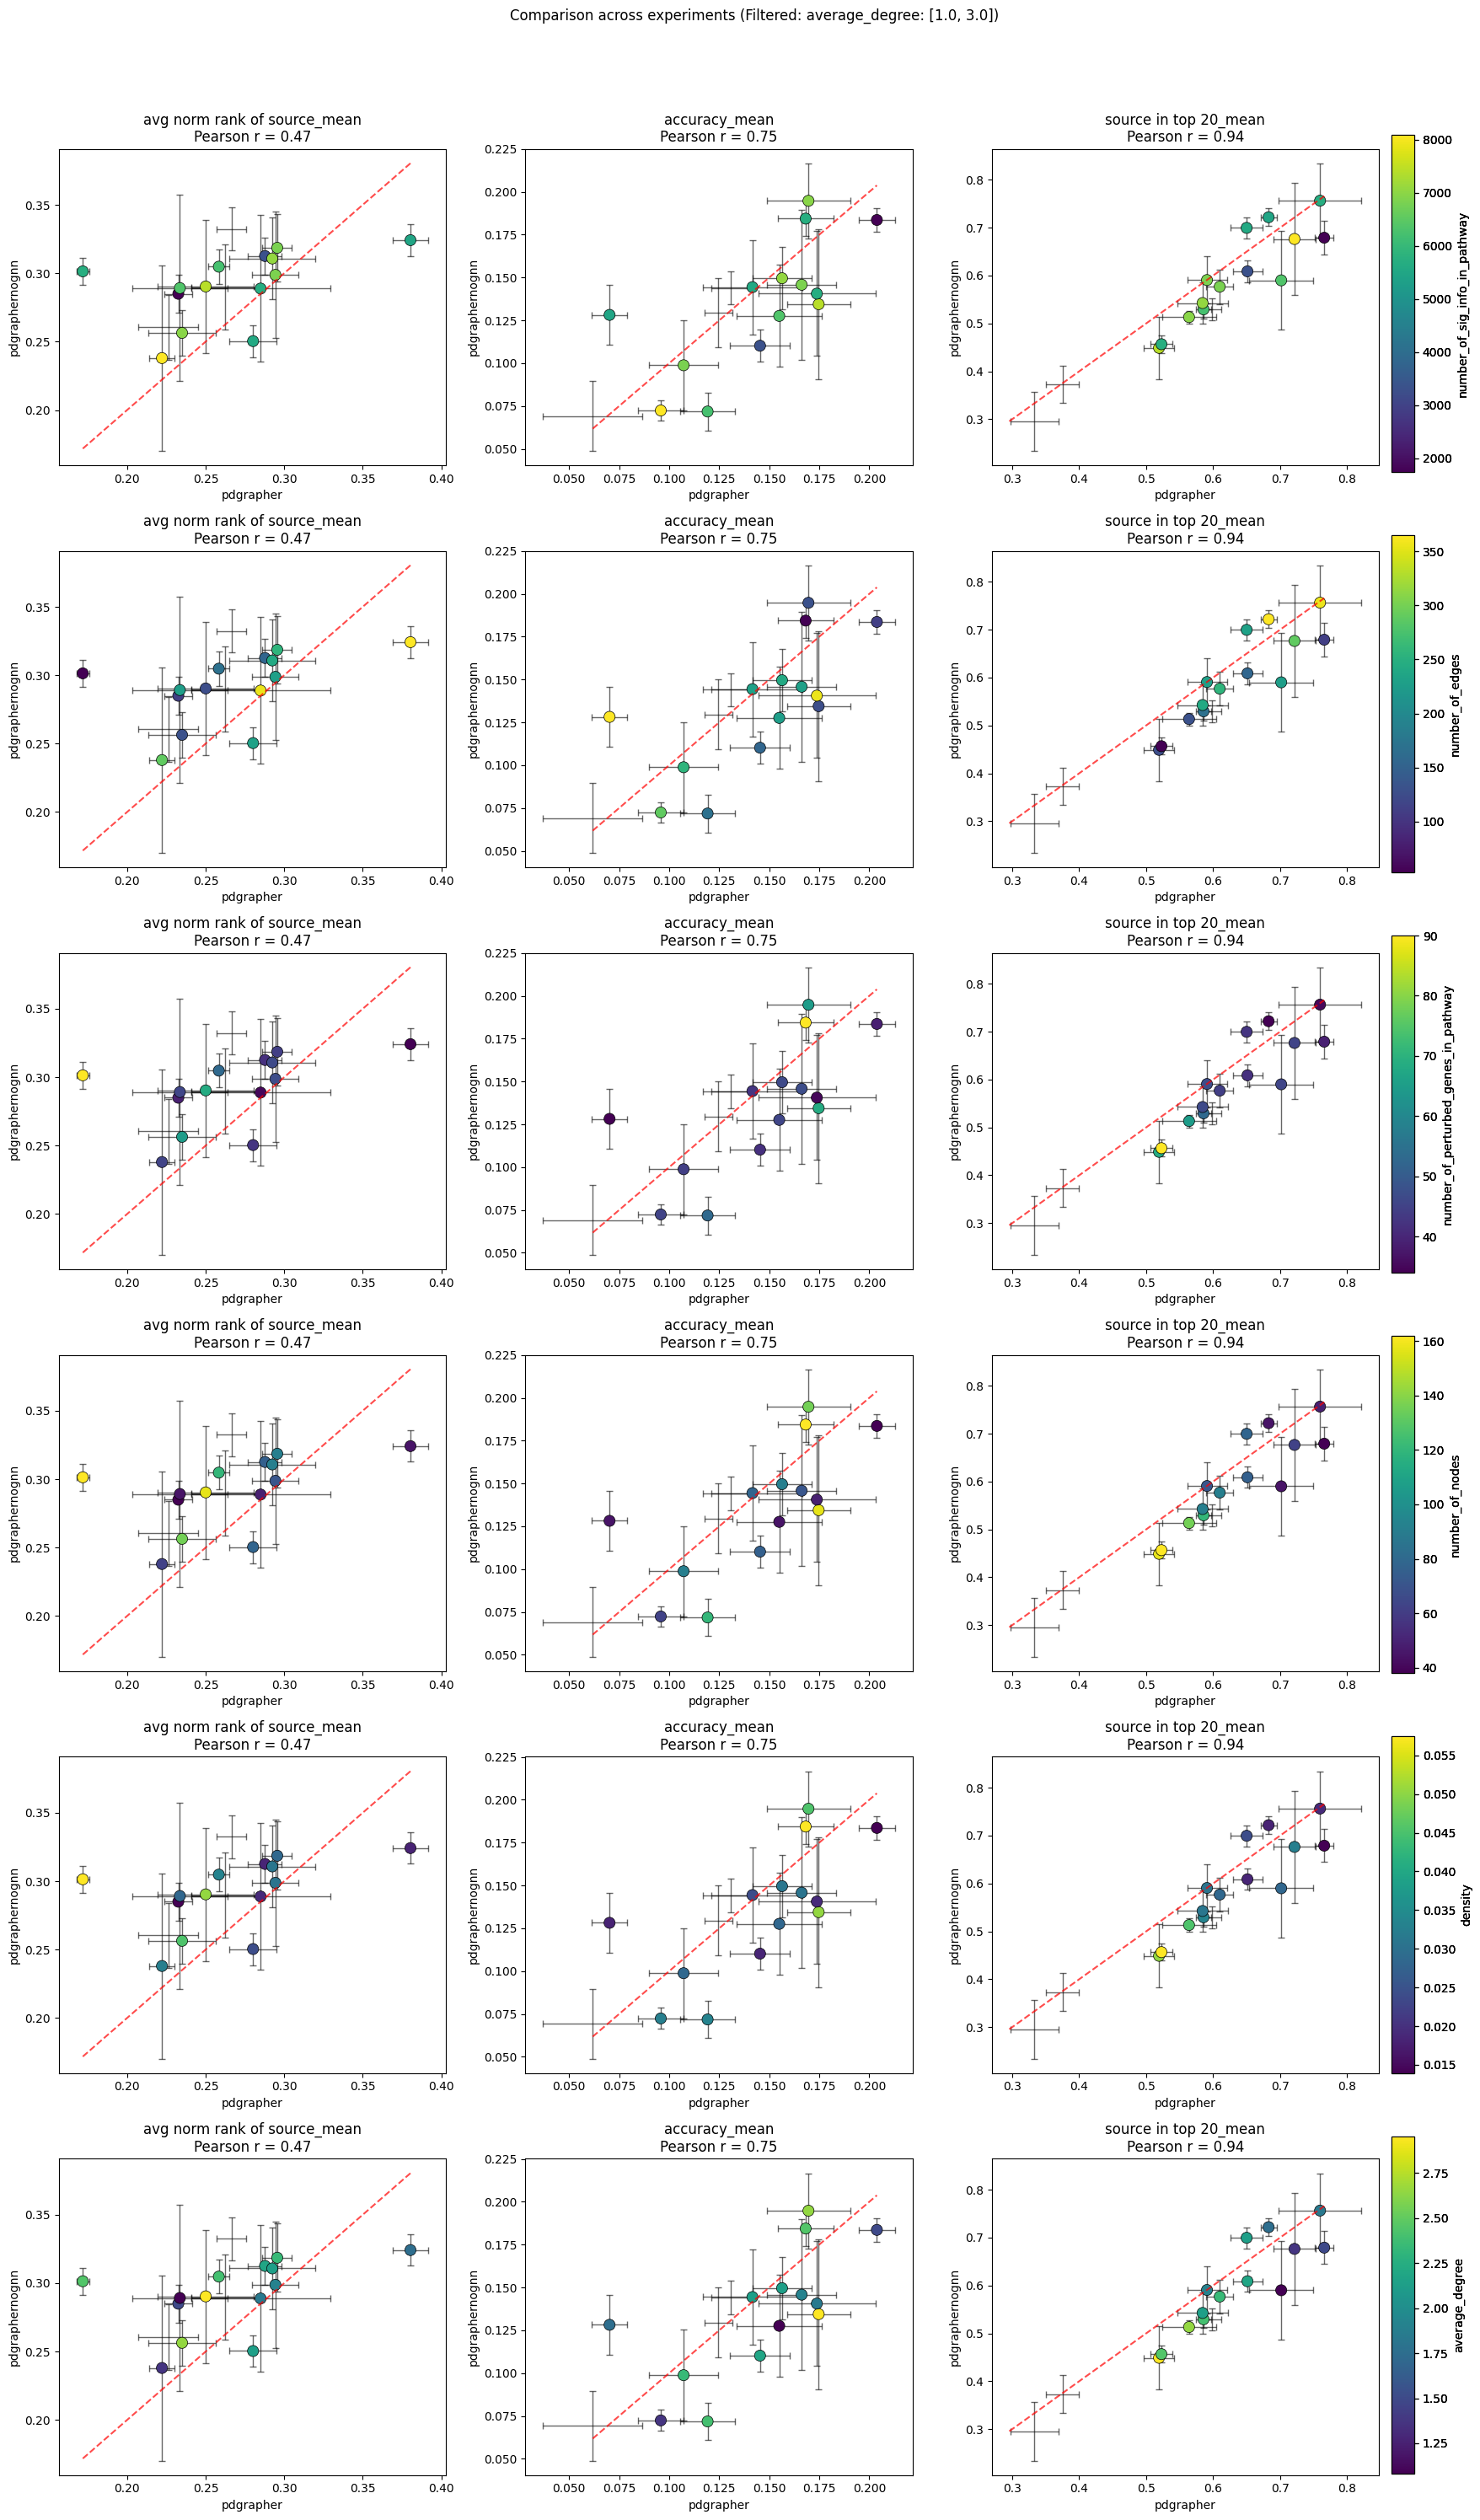

In [ ]:
# =========================
# Plot grid: rows = metadata metrics, columns = metrics
# =========================

num_meta = len(metadata_metrics)
num_perf = len(metrics)

fig, axs = plt.subplots(num_meta, num_perf, figsize=(6 * num_perf, 5 * num_meta))

if num_meta == 1:
    axs = np.array([axs])
if num_perf == 1:
    axs = axs.reshape(num_meta, 1)

for row_idx, meta_metric in enumerate(metadata_metrics):

    # Collect all values for this metadata metric for normalization
    meta_values = []
    for perf_metric in metrics:
        normalized_exps = [
            normalize_name(exp) for exp in data[perf_metric]["experiment"]
        ]
        for exp_name in normalized_exps:
            if exp_name in kegg_all_metrics:
                meta_values.append(kegg_all_metrics[exp_name].get(meta_metric, np.nan))

    meta_values = np.array(meta_values, dtype=float)
    meta_values = meta_values[~np.isnan(meta_values)]

    if len(meta_values) == 0:
        print(f"No data for metadata metric '{meta_metric}', skipping row.")
        continue

    vmin, vmax = np.min(meta_values), np.max(meta_values)

    if vmin > 0 and vmax / vmin >= 100:
        norm = LogNorm(vmin=vmin, vmax=vmax)
        cbar_label = f"{meta_metric} (log scale)"
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)
        cbar_label = meta_metric

    mappable = None

    for col_idx, perf_metric in enumerate(metrics):
        ax = axs[row_idx, col_idx]

        x = data[perf_metric]["pdgrapher"]
        y = data[perf_metric]["pdgraphernognn"]
        xerr = data[perf_metric]["pdgrapher_std"]
        yerr = data[perf_metric]["pdgraphernognn_std"]
        exps = data[perf_metric]["experiment"]

        # Get metadata values for current metric
        avg_meta = []
        for exp in exps:
            avg_meta.append(
                kegg_all_metrics.get(normalize_name(exp), {}).get(meta_metric, np.nan)
            )

        scatter = ax.scatter(
            x,
            y,
            c=avg_meta,
            cmap="viridis",
            norm=norm,
            s=90,
            edgecolors="black",
            linewidths=0.5,
            zorder=2,
        )

        mappable = scatter

        ax.errorbar(
            x,
            y,
            xerr=xerr,
            yerr=yerr,
            fmt="none",
            ecolor="black",
            elinewidth=1,
            alpha=0.6,
            capsize=3,
            zorder=1,
        )

        if len(x) > 1:
            corr, _ = pearsonr(x, y)
            ax.set_title(f"{perf_metric}\nPearson r = {corr:.2f}")
        else:
            ax.set_title(perf_metric)

        ax.set_xlabel("pdgrapher")
        ax.set_ylabel("pdgraphernognn")

        diag_min = min(min(x), min(y))
        diag_max = max(max(x), max(y))
        ax.plot([diag_min, diag_max], [diag_min, diag_max], "r--", alpha=0.7)

        cax = fig.add_axes([
            0.92,                              # x position (same for all rows)
            row_idx * (0.95 / num_meta) + 0.02,  # y position per row
            0.015,                             # width
            0.8 / num_meta                     # height per row
        ])

        cbar = fig.colorbar(mappable, cax=cax)
        cbar.set_label(cbar_label)

# Add filter info to title
filter_info = ""
if metadata_ranges:
    filter_parts = [f"{k}: [{v[0]}, {v[1]}]" for k, v in metadata_ranges.items()]
    filter_info = f" (Filtered: {', '.join(filter_parts)})"
fig.suptitle(f"Comparison across experiments{filter_info}", fontsize=12, y=0.995)

plt.tight_layout(rect=[0, 0, 0.92, 0.97])

output_filename = "comparison_scatter_plots_grid.png"
plt.savefig(output_filename)
print(f"Saved plot to {output_filename}")
plt.close(fig)
fig
